In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


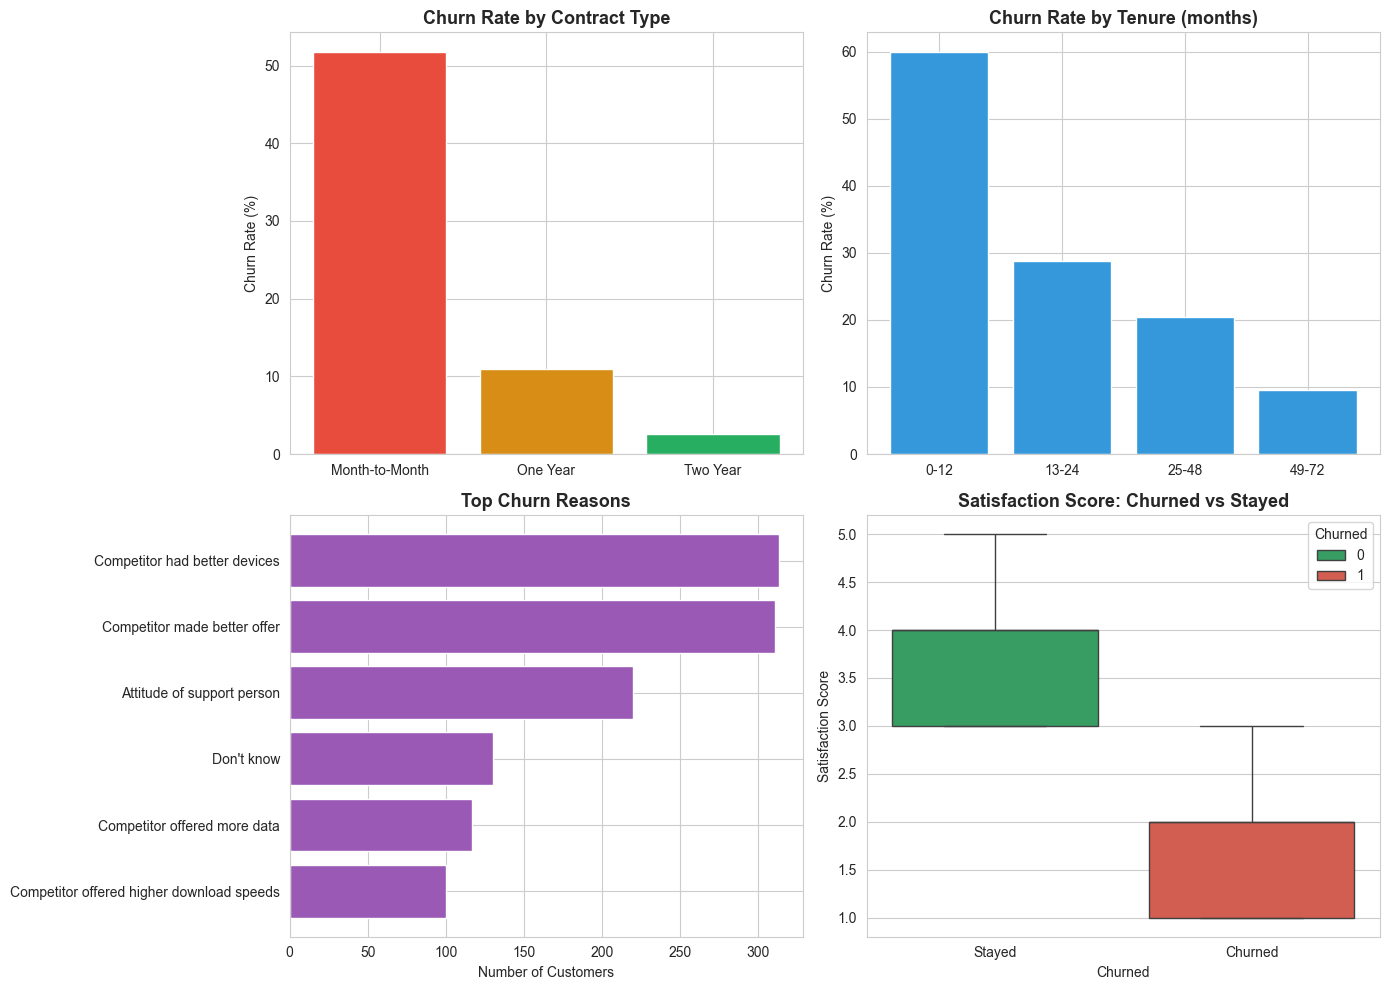

In [13]:

sns.set_style('whitegrid')
df = pd.read_csv('cleaned_telco.csv')

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Churn by Contract
contract_churn = df.groupby('Contract')['Churned'].mean().sort_values(ascending=False)*100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#e74c3c',"#d78d16",'#27ae60'])
axes[0,0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')


# 2. Churn by Tenure
df['Tenure Bucket'] = pd.cut(df['Tenure in Months'], bins=[0,12,24,48,72], labels=['0-12','13-24','25-48','49-72'])
tenure_churn = df.groupby('Tenure Bucket', observed=True)['Churned'].mean()*100
axes[0,1].bar(tenure_churn.index.astype(str), tenure_churn.values, color='#3498db')
axes[0,1].set_title('Churn Rate by Tenure (months)', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')


# 3. Top churn reasons
top_reasons = df[df['Churned']==1]['Churn Reason'].value_counts().head(6)
axes[1,0].barh(top_reasons.index[::-1], top_reasons.values[::-1], color='#9b59b6')
axes[1,0].set_title('Top Churn Reasons', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Number of Customers')


# 4. Satisfaction score distribution
sns.boxplot(data=df, x='Churned', y='Satisfaction Score',hue= 'Churned' ,ax=axes[1,1], palette=['#27ae60','#e74c3c'])
axes[1,1].set_xticks([0,1])
axes[1,1].set_xticklabels(['Stayed','Churned'])
axes[1,1].set_title('Satisfaction Score: Churned vs Stayed', fontsize=13, fontweight='bold')


plt.tight_layout()
plt.savefig('churn_analysis_charts.png', dpi=150, bbox_inches='tight')

